# Forecasting Access and Digital Payment Usage

In [1]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


current_path = Path.cwd().resolve()

if current_path.name == "notebooks":
    project_root = current_path.parent
else:
    project_root = current_path

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print("Project root:", project_root)

Project root: C:\Users\bemnet\Desktop\10academy\newWeek11\new-ethiopia-fi-forcast


In [4]:
observations_df = enriched_df[
    enriched_df["record_type"]
    .astype(str)
    .str.lower()
    .eq("observation")
].copy()


if "year" not in observations_df.columns:
    if "observation_date" not in observations_df.columns:
        raise KeyError(
            "Neither 'year' nor 'observation_date' "
            "exists in the dataset."
        )

    observations_df["observation_date"] = pd.to_datetime(
        observations_df["observation_date"],
        errors="coerce",
    )

    observations_df["year"] = (
        observations_df["observation_date"].dt.year
    )

else:
    observations_df["year"] = pd.to_numeric(
        observations_df["year"],
        errors="coerce",
    )


observations_df["value_numeric"] = pd.to_numeric(
    observations_df["value_numeric"],
    errors="coerce",
)

print("Observation records:", len(observations_df))
print(
    "Observation years:",
    sorted(
        observations_df["year"]
        .dropna()
        .astype(int)
        .unique()
        .tolist()
    ),
)

Observation records: 45
Observation years: [2011, 2014, 2017, 2021, 2023, 2024, 2025]


## Forecast Targets

In [5]:
forecast_targets = {
    "Access": {
        "indicator_code": "ACC_OWNERSHIP",
        "target_name": "Account Ownership Rate",
        "definition": (
            "Percentage of adults with an account at a financial "
            "institution or mobile money provider"
        ),
    },

    "Usage": {
        "indicator_code": "USG_DIGITAL_PAYMENT_RATE",
        "target_name": "Digital Payment Usage",
        "definition": (
            "Percentage of adults who made or received a "
            "digital payment"
        ),
    },
}

target_definitions = pd.DataFrame(
    [
        {
            "pillar": pillar,
            **details,
        }
        for pillar, details in forecast_targets.items()
    ]
)

target_definitions

,pillar,indicator_code,target_name,definition
0,Access,ACC_OWNERSHIP,Account Ownership Rate,Percentage of adults with an account at a fina...
1,Usage,USG_DIGITAL_PAYMENT_RATE,Digital Payment Usage,Percentage of adults who made or received a di...


In [6]:
def keep_national_overall_records(df):
    """
    Keep national or overall observations and remove
    demographic disaggregations where possible.
    """

    result = df.copy()

    if "gender" in result.columns:
        gender_value = (
            result["gender"]
            .fillna("")
            .astype(str)
            .str.strip()
            .str.lower()
        )

        result = result[
            gender_value.isin(
                [
                    "",
                    "all",
                    "overall",
                    "national",
                    "both",
                    "total",
                ]
            )
        ]

    if "location" in result.columns:
        location_value = (
            result["location"]
            .fillna("")
            .astype(str)
            .str.strip()
            .str.lower()
        )

        result = result[
            location_value.isin(
                [
                    "",
                    "national",
                    "all",
                    "overall",
                    "ethiopia",
                    "total",
                ]
            )
        ]

    return result

## Access target

In [7]:
access_target = observations_df[
    observations_df["indicator_code"]
    .astype(str)
    .str.strip()
    .eq("ACC_OWNERSHIP")
].copy()

access_target = keep_national_overall_records(
    access_target
)

In [8]:
access_columns = [
    column
    for column in [
        "year",
        "observation_date",
        "value_numeric",
        "unit",
        "confidence",
        "source_name",
    ]
    if column in access_target.columns
]

access_target = access_target[
    access_columns
].copy()

In [9]:
access_target = (
    access_target
    .dropna(
        subset=[
            "year",
            "value_numeric",
        ]
    )
    .assign(
        year=lambda df: df["year"].astype(int)
    )
    .groupby(
        "year",
        as_index=False,
    )
    .agg(
        access_rate=(
            "value_numeric",
            "mean",
        )
    )
    .sort_values("year")
    .reset_index(drop=True)
)

access_target

,year,access_rate
0,2011,14.0
1,2014,22.0
2,2017,35.0
3,2021,46.0
4,2024,49.0


## Usage target

In [10]:
usage_target = observations_df[
    observations_df["indicator_code"]
    .astype(str)
    .str.strip()
    .eq("USG_DIGITAL_PAYMENT_RATE")
].copy()

usage_target = keep_national_overall_records(
    usage_target
)

In [11]:
usage_columns = [
    column
    for column in [
        "year",
        "observation_date",
        "value_numeric",
        "unit",
        "confidence",
        "source_name",
    ]
    if column in usage_target.columns
]

usage_target = usage_target[
    usage_columns
].copy()

In [12]:
usage_target = (
    usage_target
    .dropna(
        subset=[
            "year",
            "value_numeric",
        ]
    )
    .assign(
        year=lambda df: df["year"].astype(int)
    )
    .groupby(
        "year",
        as_index=False,
    )
    .agg(
        usage_rate=(
            "value_numeric",
            "mean",
        )
    )
    .sort_values("year")
    .reset_index(drop=True)
)

usage_target

,year,usage_rate
0,2024,35.0


In [13]:
def get_first_year(df):
    if df.empty:
        return np.nan

    return int(df["year"].min())


def get_latest_year(df):
    if df.empty:
        return np.nan

    return int(df["year"].max())


target_readiness = pd.DataFrame({
    "target": [
        "Account Ownership Rate",
        "Digital Payment Usage",
    ],

    "indicator_code": [
        "ACC_OWNERSHIP",
        "USG_DIGITAL_PAYMENT_RATE",
    ],

    "historical_observations": [
        len(access_target),
        len(usage_target),
    ],

    "first_year": [
        get_first_year(access_target),
        get_first_year(usage_target),
    ],

    "latest_year": [
        get_latest_year(access_target),
        get_latest_year(usage_target),
    ],

    "forecast_period": [
        "2025-2027",
        "2025-2027",
    ],
})

target_readiness

,target,indicator_code,historical_observations,first_year,latest_year,forecast_period
0,Account Ownership Rate,ACC_OWNERSHIP,5,2011,2024,2025-2027
1,Digital Payment Usage,USG_DIGITAL_PAYMENT_RATE,1,2024,2024,2025-2027


In [14]:
forecast_years = np.array(
    [
        2025,
        2026,
        2027,
    ]
)

forecast_horizon = pd.DataFrame({
    "year": forecast_years,
    "period": "Forecast",
})

forecast_horizon

,year,period
0,2025,Forecast
1,2026,Forecast
2,2027,Forecast


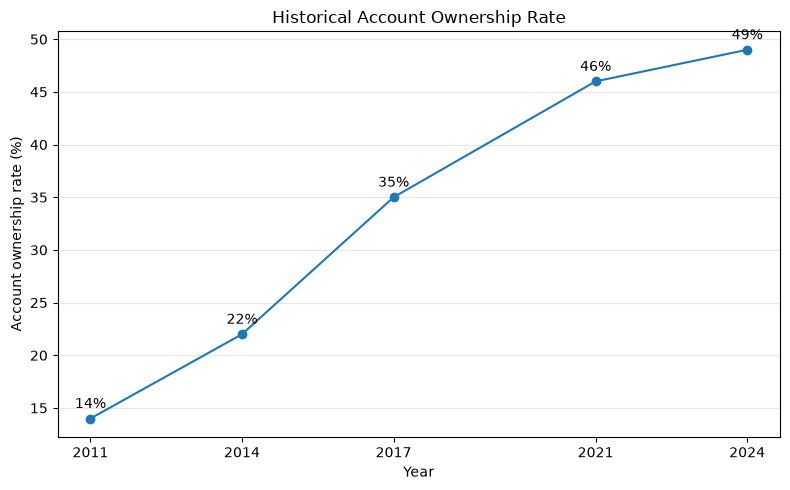

In [15]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.plot(
    access_target["year"],
    access_target["access_rate"],
    marker="o",
)

for _, row in access_target.iterrows():
    ax.text(
        row["year"],
        row["access_rate"] + 1,
        f'{row["access_rate"]:.0f}%',
        ha="center",
    )

ax.set_title(
    "Historical Account Ownership Rate"
)

ax.set_xlabel("Year")
ax.set_ylabel("Account ownership rate (%)")
ax.set_xticks(access_target["year"])
ax.grid(
    axis="y",
    alpha=0.3,
)

plt.tight_layout()
plt.show()

In [16]:
print("=" * 60)
print("FORECAST TARGET DEFINITION")
print("=" * 60)

print("\nAccess target: ACC_OWNERSHIP")
print(
    "Access historical observations:",
    len(access_target),
)

if not access_target.empty:
    print(
        "Access coverage:",
        f"{access_target['year'].min()}-"
        f"{access_target['year'].max()}",
    )


print(
    "\nUsage target:",
    "USG_DIGITAL_PAYMENT_RATE",
)

print(
    "Usage historical observations:",
    len(usage_target),
)

if not usage_target.empty:
    print(
        "Usage coverage:",
        f"{usage_target['year'].min()}-"
        f"{usage_target['year'].max()}",
    )


print("\nForecast horizon: 2025-2027")

print(
    "\nModeling decision:",
    "Separate forecasting approaches are required "
    "for Access and Usage.",
)

FORECAST TARGET DEFINITION

Access target: ACC_OWNERSHIP
Access historical observations: 5
Access coverage: 2011-2024

Usage target: USG_DIGITAL_PAYMENT_RATE
Usage historical observations: 1
Usage coverage: 2024-2024

Forecast horizon: 2025-2027

Modeling decision: Separate forecasting approaches are required for Access and Usage.


## Forecasting Approach

In [17]:
access_model_df = access_target.copy()

access_model_df["time_index"] = (
    access_model_df["year"]
    - access_model_df["year"].min()
)

access_model_df

,year,access_rate,time_index
0,2011,14.0,0
1,2014,22.0,3
2,2017,35.0,6
3,2021,46.0,10
4,2024,49.0,13


In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error


X_access = access_model_df[
    ["time_index"]
]

y_access = access_model_df[
    "access_rate"
]


linear_access_model = LinearRegression()

linear_access_model.fit(
    X_access,
    y_access,
)

access_model_df[
    "linear_fitted"
] = linear_access_model.predict(
    X_access
)

linear_mae = mean_absolute_error(
    y_access,
    access_model_df["linear_fitted"],
)

print(
    "Linear annual growth:",
    round(
        linear_access_model.coef_[0],
        3,
    ),
    "percentage points",
)

print(
    "Linear MAE:",
    round(linear_mae, 3),
)

Linear annual growth: 2.844 percentage points
Linear MAE: 2.199


In [20]:
access_model_df[
    "log_time"
] = np.log1p(
    access_model_df["time_index"]
)

log_access_model = LinearRegression()

log_access_model.fit(
    access_model_df[["log_time"]],
    y_access,
)

access_model_df[
    "log_fitted"
] = log_access_model.predict(
    access_model_df[["log_time"]]
)

log_mae = mean_absolute_error(
    y_access,
    access_model_df["log_fitted"],
)

print(
    "Log-time MAE:",
    round(log_mae, 3),
)

Log-time MAE: 3.675


In [21]:
recent_access = access_model_df[
    access_model_df["year"].isin(
        [2021, 2024]
    )
].copy()

recent_start = recent_access.iloc[0]
recent_end = recent_access.iloc[-1]

recent_years = (
    recent_end["year"]
    - recent_start["year"]
)

recent_annual_growth = (
    recent_end["access_rate"]
    - recent_start["access_rate"]
) / recent_years

print(
    "Recent annual growth:",
    round(
        recent_annual_growth,
        2,
    ),
    "percentage points per year",
)

Recent annual growth: 1.0 percentage points per year


## preliminary trend forecasts

In [22]:
forecast_years = np.array([
    2025,
    2026,
    2027,
])

forecast_time_index = (
    forecast_years
    - access_model_df["year"].min()
)

trend_forecasts = pd.DataFrame({
    "year": forecast_years,
})

## Long-term linear forecast

In [23]:
trend_forecasts[
    "long_term_linear"
] = linear_access_model.predict(
    pd.DataFrame({
        "time_index": (
            forecast_time_index
        ),
    })
)

## Log-time forecast

In [24]:
trend_forecasts[
    "log_trend"
] = log_access_model.predict(
    pd.DataFrame({
        "log_time": np.log1p(
            forecast_time_index
        ),
    })
)

## Recent-growth forecast

In [25]:
latest_access_year = int(
    access_model_df["year"].max()
)

latest_access_rate = float(
    access_model_df.loc[
        access_model_df["year"]
        == latest_access_year,
        "access_rate",
    ].iloc[0]
)

trend_forecasts[
    "recent_growth"
] = (
    latest_access_rate
    + recent_annual_growth
    * (
        trend_forecasts["year"]
        - latest_access_year
    )
)

trend_forecasts

,year,long_term_linear,log_trend,recent_growth
0,2025,54.816850,47.342973,50.0
1,2026,57.661172,48.225539,51.0
2,2027,60.505495,49.054582,52.0


## Comparision

In [26]:
model_comparison = pd.DataFrame({
    "approach": [
        "Long-term linear regression",
        "Log-time regression",
        "Recent observed growth",
    ],

    "strength": [
        (
            "Uses the complete Access history "
            "and is easy to interpret."
        ),
        (
            "Allows growth to slow as inclusion "
            "becomes more mature."
        ),
        (
            "Reflects the latest observed slowdown."
        ),
    ],

    "limitation": [
        (
            "May overstate future growth because "
            "earlier expansion was faster."
        ),
        (
            "Still relies on only five historical "
            "observations."
        ),
        (
            "Relies on only the 2021 and 2024 "
            "observations."
        ),
    ],

    "recommended_use": [
        "High-growth reference",
        "Base trend reference",
        "Low-growth reference",
    ],
})

model_comparison

,approach,strength,limitation,recommended_use
0,Long-term linear regression,Uses the complete Access history and is easy t...,May overstate future growth because earlier ex...,High-growth reference
1,Log-time regression,Allows growth to slow as inclusion becomes mor...,Still relies on only five historical observati...,Base trend reference
2,Recent observed growth,Reflects the latest observed slowdown.,Relies on only the 2021 and 2024 observations.,Low-growth reference


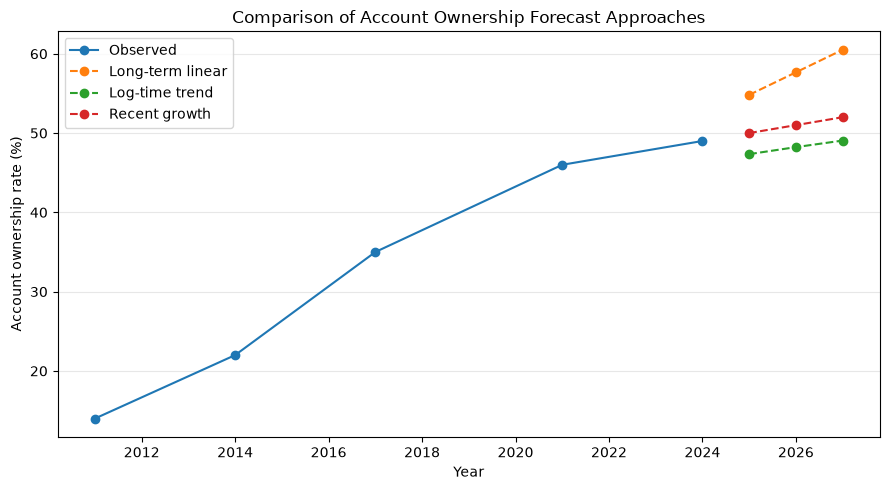

In [27]:
fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.plot(
    access_model_df["year"],
    access_model_df["access_rate"],
    marker="o",
    label="Observed",
)

ax.plot(
    trend_forecasts["year"],
    trend_forecasts["long_term_linear"],
    marker="o",
    linestyle="--",
    label="Long-term linear",
)

ax.plot(
    trend_forecasts["year"],
    trend_forecasts["log_trend"],
    marker="o",
    linestyle="--",
    label="Log-time trend",
)

ax.plot(
    trend_forecasts["year"],
    trend_forecasts["recent_growth"],
    marker="o",
    linestyle="--",
    label="Recent growth",
)

ax.set_title(
    "Comparison of Account Ownership Forecast Approaches"
)

ax.set_xlabel("Year")
ax.set_ylabel("Account ownership rate (%)")
ax.legend()
ax.grid(
    axis="y",
    alpha=0.3,
)

plt.tight_layout()
plt.show()

In [28]:
access_scenario_basis = pd.DataFrame({
    "scenario": [
        "Low",
        "Base",
        "High",
    ],

    "trend_basis": [
        "Recent observed growth",
        "Log-time trend",
        "Long-term linear trend",
    ],

    "interpretation": [
        (
            "Recent slowdown continues and event "
            "effects remain limited."
        ),
        (
            "Growth continues gradually with moderate "
            "support from market and policy events."
        ),
        (
            "Infrastructure, interoperability, mobile "
            "money, and digital ID accelerate inclusion."
        ),
    ],
})

access_scenario_basis

,scenario,trend_basis,interpretation
0,Low,Recent observed growth,Recent slowdown continues and event effects re...
1,Base,Log-time trend,Growth continues gradually with moderate suppo...
2,High,Long-term linear trend,"Infrastructure, interoperability, mobile money..."


In [29]:
usage_model_decision = pd.DataFrame({
    "component": [
        "Starting point",
        "Historical model",
        "Supporting indicators",
        "Event evidence",
        "Forecast structure",
    ],

    "selected_approach": [
        "2024 Digital Payment Usage rate",
        "No standalone regression",
        (
            "Mobile money accounts, active-account rates, "
            "P2P activity, POS activity and merchant acceptance"
        ),
        (
            "Reuse refined Usage impact estimates "
            "from Task 3"
        ),
        "Low, base and high scenarios",
    ],
})

usage_model_decision

,component,selected_approach
0,Starting point,2024 Digital Payment Usage rate
1,Historical model,No standalone regression
2,Supporting indicators,"Mobile money accounts, active-account rates, P..."
3,Event evidence,Reuse refined Usage impact estimates from Task 3
4,Forecast structure,"Low, base and high scenarios"


In [30]:
selected_forecasting_methods = pd.DataFrame({
    "target": [
        "Account Ownership Rate",
        "Digital Payment Usage",
    ],

    "primary_method": [
        "Trend-based scenario model",
        "Baseline-driven scenario model",
    ],

    "base_case": [
        "Log-time Access trend",
        "2024 baseline plus assumed annual growth",
    ],

    "event_use": [
        (
            "Qualitative adjustment based on refined "
            "Access impact estimates"
        ),
        (
            "Qualitative adjustment based on refined "
            "Usage impact estimates"
        ),
    ],

    "uncertainty": [
        "Low, base and high scenarios",
        "Low, base and high scenarios",
    ],
})

selected_forecasting_methods

,target,primary_method,base_case,event_use,uncertainty
0,Account Ownership Rate,Trend-based scenario model,Log-time Access trend,Qualitative adjustment based on refined Access...,"Low, base and high scenarios"
1,Digital Payment Usage,Baseline-driven scenario model,2024 baseline plus assumed annual growth,Qualitative adjustment based on refined Usage ...,"Low, base and high scenarios"


In [31]:
print("=" * 60)
print("FORECASTING APPROACH SELECTION")
print("=" * 60)

print(
    "\nAccess historical observations:",
    len(access_target),
)

print(
    "Usage historical observations:",
    len(usage_target),
)

print(
    "\nAccess approach:",
    "Trend-based scenario model",
)

print(
    "Access base trend:",
    "Log-time regression",
)

print(
    "Access low reference:",
    "Recent annual growth",
)

print(
    "Access high reference:",
    "Long-term linear regression",
)

print(
    "\nUsage approach:",
    "2024 baseline plus scenario growth assumptions",
)

print(
    "\nEvent effects:",
    "Reused from Task 3 as scenario evidence, "
    "not direct percentage-point additions",
)

FORECASTING APPROACH SELECTION

Access historical observations: 5
Usage historical observations: 1

Access approach: Trend-based scenario model
Access base trend: Log-time regression
Access low reference: Recent annual growth
Access high reference: Long-term linear regression

Usage approach: 2024 baseline plus scenario growth assumptions

Event effects: Reused from Task 3 as scenario evidence, not direct percentage-point additions


## Forecast Generation

### Access baseline

In [32]:
access_baseline = pd.DataFrame({
    "year": forecast_years,
})

access_baseline["baseline"] = (
    latest_access_rate
    + recent_annual_growth
    * (
        access_baseline["year"]
        - latest_access_year
    )
)

access_baseline

,year,baseline
0,2025,50.0
1,2026,51.0
2,2027,52.0


#### expected event developments

In [33]:
access_event_adjustments = pd.DataFrame({
    "year": forecast_years,

    # Cumulative percentage-point adjustments
    "event_adjustment": [
        0.3,
        0.7,
        1.2,
    ],
})

access_with_events = access_baseline.merge(
    access_event_adjustments,
    on="year",
    how="left",
)

access_with_events["with_events"] = (
    access_with_events["baseline"]
    + access_with_events["event_adjustment"]
)

access_with_events

,year,baseline,event_adjustment,with_events
0,2025,50.0,0.3,50.3
1,2026,51.0,0.7,51.7
2,2027,52.0,1.2,53.2


#### Access scenarios

In [34]:
access_scenarios = pd.DataFrame({
    "year": forecast_years,
})

years_after_2024 = (
    access_scenarios["year"]
    - latest_access_year
)

access_scenarios["pessimistic"] = (
    latest_access_rate
    + 0.5 * years_after_2024
)

access_scenarios["base"] = (
    access_with_events["with_events"]
)

access_scenarios["optimistic"] = (
    latest_access_rate
    + 1.5 * years_after_2024
)

access_scenarios

,year,pessimistic,base,optimistic
0,2025,49.5,50.3,50.5
1,2026,50.0,51.7,52.0
2,2027,50.5,53.2,53.5


### Usage baseline

In [35]:
latest_usage_year = int(
    usage_target["year"].max()
)

latest_usage_rate = float(
    usage_target.loc[
        usage_target["year"]
        == latest_usage_year,
        "usage_rate",
    ].iloc[0]
)

print("Usage baseline year:", latest_usage_year)
print("Usage baseline rate:", latest_usage_rate)

Usage baseline year: 2024
Usage baseline rate: 35.0


In [36]:
usage_baseline = pd.DataFrame({
    "year": forecast_years,
})

usage_years_after_2024 = (
    usage_baseline["year"]
    - latest_usage_year
)

usage_baseline["baseline"] = (
    latest_usage_rate
    + 2.5 * usage_years_after_2024
)

usage_baseline

,year,baseline
0,2025,37.5
1,2026,40.0
2,2027,42.5


In [37]:
usage_event_adjustments = pd.DataFrame({
    "year": forecast_years,

    # Cumulative percentage-point adjustments
    "event_adjustment": [
        0.5,
        1.5,
        3.0,
    ],
})

usage_with_events = usage_baseline.merge(
    usage_event_adjustments,
    on="year",
    how="left",
)

usage_with_events["with_events"] = (
    usage_with_events["baseline"]
    + usage_with_events["event_adjustment"]
)

usage_with_events

,year,baseline,event_adjustment,with_events
0,2025,37.5,0.5,38.0
1,2026,40.0,1.5,41.5
2,2027,42.5,3.0,45.5


In [38]:
usage_scenarios = pd.DataFrame({
    "year": forecast_years,
})

usage_scenarios["pessimistic"] = (
    latest_usage_rate
    + 1.5 * usage_years_after_2024
)

usage_scenarios["base"] = (
    usage_with_events["with_events"]
)

usage_scenarios["optimistic"] = (
    latest_usage_rate
    + 5.0 * usage_years_after_2024
)

# Keep percentage forecasts within 0–100
usage_scenarios[
    [
        "pessimistic",
        "base",
        "optimistic",
    ]
] = usage_scenarios[
    [
        "pessimistic",
        "base",
        "optimistic",
    ]
].clip(
    lower=0,
    upper=100,
)

usage_scenarios

,year,pessimistic,base,optimistic
0,2025,36.5,38.0,40.0
1,2026,38.0,41.5,45.0
2,2027,39.5,45.5,50.0


In [39]:
access_forecast_long = access_scenarios.melt(
    id_vars="year",
    var_name="scenario",
    value_name="forecast_rate",
)

access_forecast_long["target"] = (
    "Account Ownership Rate"
)

usage_forecast_long = usage_scenarios.melt(
    id_vars="year",
    var_name="scenario",
    value_name="forecast_rate",
)

usage_forecast_long["target"] = (
    "Digital Payment Usage"
)

final_forecasts = pd.concat(
    [
        access_forecast_long,
        usage_forecast_long,
    ],
    ignore_index=True,
)

final_forecasts = final_forecasts[
    [
        "target",
        "year",
        "scenario",
        "forecast_rate",
    ]
].sort_values(
    [
        "target",
        "scenario",
        "year",
    ]
).reset_index(drop=True)

final_forecasts

,target,year,scenario,forecast_rate
0,Account Ownership Rate,2025,base,50.3
1,Account Ownership Rate,2026,base,51.7
2,Account Ownership Rate,2027,base,53.2
3,Account Ownership Rate,2025,optimistic,50.5
4,Account Ownership Rate,2026,optimistic,52.0
5,Account Ownership Rate,2027,optimistic,53.5
6,Account Ownership Rate,2025,pessimistic,49.5
7,Account Ownership Rate,2026,pessimistic,50.0
8,Account Ownership Rate,2027,pessimistic,50.5
9,Digital Payment Usage,2025,base,38.0


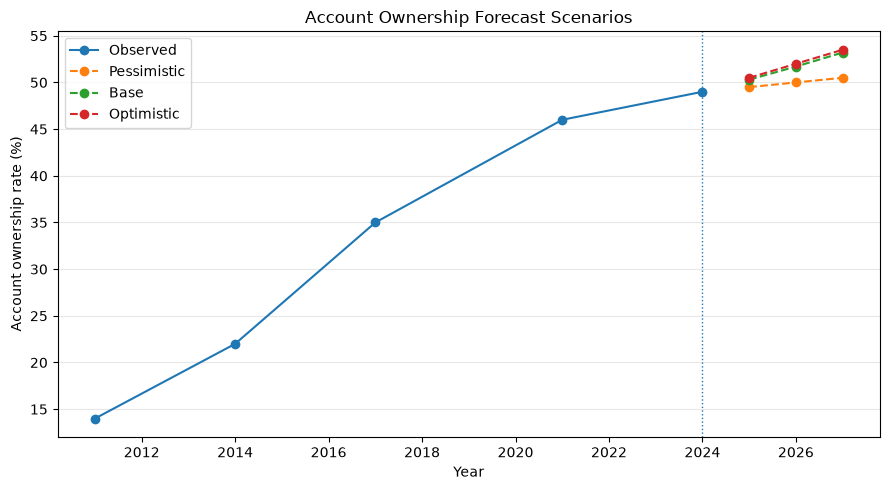

In [40]:
fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.plot(
    access_target["year"],
    access_target["access_rate"],
    marker="o",
    label="Observed",
)

for scenario in [
    "pessimistic",
    "base",
    "optimistic",
]:
    ax.plot(
        access_scenarios["year"],
        access_scenarios[scenario],
        marker="o",
        linestyle="--",
        label=scenario.capitalize(),
    )

ax.axvline(
    2024,
    linestyle=":",
    linewidth=1,
)

ax.set_title(
    "Account Ownership Forecast Scenarios"
)

ax.set_xlabel("Year")
ax.set_ylabel("Account ownership rate (%)")
ax.legend()
ax.grid(
    axis="y",
    alpha=0.3,
)

plt.tight_layout()
plt.show()

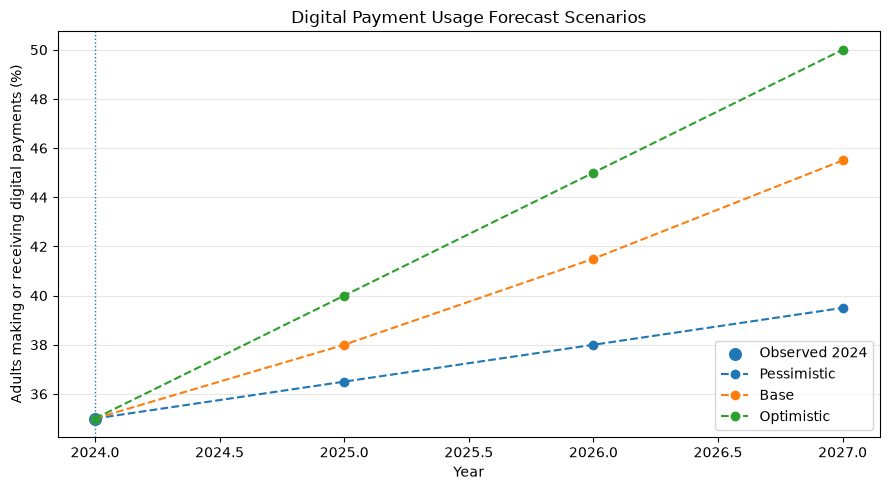

In [41]:
fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.scatter(
    usage_target["year"],
    usage_target["usage_rate"],
    s=70,
    label="Observed 2024",
)

for scenario in [
    "pessimistic",
    "base",
    "optimistic",
]:
    scenario_years = np.insert(
        usage_scenarios["year"].to_numpy(),
        0,
        latest_usage_year,
    )

    scenario_values = np.insert(
        usage_scenarios[scenario].to_numpy(),
        0,
        latest_usage_rate,
    )

    ax.plot(
        scenario_years,
        scenario_values,
        marker="o",
        linestyle="--",
        label=scenario.capitalize(),
    )

ax.axvline(
    2024,
    linestyle=":",
    linewidth=1,
)

ax.set_title(
    "Digital Payment Usage Forecast Scenarios"
)

ax.set_xlabel("Year")
ax.set_ylabel("Adults making or receiving digital payments (%)")
ax.legend()
ax.grid(
    axis="y",
    alpha=0.3,
)

plt.tight_layout()
plt.show()

In [42]:
base_forecast_summary = pd.DataFrame({
    "target": [
        "Account Ownership Rate",
        "Digital Payment Usage",
    ],

    "2025": [
        access_scenarios.loc[
            access_scenarios["year"] == 2025,
            "base",
        ].iloc[0],

        usage_scenarios.loc[
            usage_scenarios["year"] == 2025,
            "base",
        ].iloc[0],
    ],

    "2026": [
        access_scenarios.loc[
            access_scenarios["year"] == 2026,
            "base",
        ].iloc[0],

        usage_scenarios.loc[
            usage_scenarios["year"] == 2026,
            "base",
        ].iloc[0],
    ],

    "2027": [
        access_scenarios.loc[
            access_scenarios["year"] == 2027,
            "base",
        ].iloc[0],

        usage_scenarios.loc[
            usage_scenarios["year"] == 2027,
            "base",
        ].iloc[0],
    ],
})

base_forecast_summary

,target,2025,2026,2027
0,Account Ownership Rate,50.3,51.7,53.2
1,Digital Payment Usage,38.0,41.5,45.5


In [43]:
print("=" * 60)
print("ACCESS AND USAGE FORECASTS")
print("=" * 60)

print("\nAccess base forecast:")
print(
    access_scenarios[
        [
            "year",
            "base",
        ]
    ].to_string(
        index=False
    )
)

print("\nUsage base forecast:")
print(
    usage_scenarios[
        [
            "year",
            "base",
        ]
    ].to_string(
        index=False
    )
)

print(
    "\nAccess 2027 scenario range:",
    f"{access_scenarios.loc[access_scenarios['year'] == 2027, 'pessimistic'].iloc[0]:.1f}%"
    " to "
    f"{access_scenarios.loc[access_scenarios['year'] == 2027, 'optimistic'].iloc[0]:.1f}%",
)

print(
    "Usage 2027 scenario range:",
    f"{usage_scenarios.loc[usage_scenarios['year'] == 2027, 'pessimistic'].iloc[0]:.1f}%"
    " to "
    f"{usage_scenarios.loc[usage_scenarios['year'] == 2027, 'optimistic'].iloc[0]:.1f}%",
)

ACCESS AND USAGE FORECASTS

Access base forecast:
 year  base
 2025  50.3
 2026  51.7
 2027  53.2

Usage base forecast:
 year  base
 2025  38.0
 2026  41.5
 2027  45.5

Access 2027 scenario range: 50.5% to 53.5%
Usage 2027 scenario range: 39.5% to 50.0%


## Forecast Uncertainty

In [44]:
from scipy.stats import t

In [45]:
access_interval_df = access_model_df.copy()

access_interval_df["linear_prediction"] = (
    linear_access_model.predict(
        access_interval_df[["time_index"]]
    )
)

access_interval_df["residual"] = (
    access_interval_df["access_rate"]
    - access_interval_df["linear_prediction"]
)

n_access = len(access_interval_df)
model_parameters = 2

degrees_of_freedom = (
    n_access - model_parameters
)

residual_standard_error = np.sqrt(
    (
        access_interval_df["residual"] ** 2
    ).sum()
    / degrees_of_freedom
)

print(
    "Residual standard error:",
    round(residual_standard_error, 2),
)

Residual standard error: 3.02


In [46]:
historical_x = (
    access_interval_df["time_index"]
    .to_numpy()
)

x_mean = historical_x.mean()

sxx = (
    (historical_x - x_mean) ** 2
).sum()

access_uncertainty = access_scenarios[
    [
        "year",
        "base",
        "pessimistic",
        "optimistic",
    ]
].copy()

access_uncertainty[
    "forecast_time_index"
] = (
    access_uncertainty["year"]
    - access_model_df["year"].min()
)

In [47]:
def prediction_standard_error(x_value):
    return residual_standard_error * np.sqrt(
        1
        + (1 / n_access)
        + (
            (x_value - x_mean) ** 2
            / sxx
        )
    )


access_uncertainty[
    "prediction_standard_error"
] = access_uncertainty[
    "forecast_time_index"
].apply(
    prediction_standard_error
)

In [48]:
t_80 = t.ppf(
    0.90,
    degrees_of_freedom,
)

t_95 = t.ppf(
    0.975,
    degrees_of_freedom,
)

access_uncertainty[
    "margin_80"
] = (
    t_80
    * access_uncertainty[
        "prediction_standard_error"
    ]
)

access_uncertainty[
    "margin_95"
] = (
    t_95
    * access_uncertainty[
        "prediction_standard_error"
    ]
)

In [49]:
access_uncertainty[
    "lower_80"
] = (
    access_uncertainty["base"]
    - access_uncertainty["margin_80"]
)

access_uncertainty[
    "upper_80"
] = (
    access_uncertainty["base"]
    + access_uncertainty["margin_80"]
)

access_uncertainty[
    "lower_95"
] = (
    access_uncertainty["base"]
    - access_uncertainty["margin_95"]
)

access_uncertainty[
    "upper_95"
] = (
    access_uncertainty["base"]
    + access_uncertainty["margin_95"]
)

In [50]:
interval_columns = [
    "lower_80",
    "upper_80",
    "lower_95",
    "upper_95",
]

access_uncertainty[
    interval_columns
] = access_uncertainty[
    interval_columns
].clip(
    lower=0,
    upper=100,
)

In [51]:
access_uncertainty[
    "scenario_lower"
] = access_uncertainty[
    "pessimistic"
]

access_uncertainty[
    "scenario_upper"
] = access_uncertainty[
    "optimistic"
]

access_uncertainty[
    [
        "year",
        "base",
        "lower_80",
        "upper_80",
        "lower_95",
        "upper_95",
        "scenario_lower",
        "scenario_upper",
    ]
].round(2)

,year,base,lower_80,upper_80,lower_95,upper_95,scenario_lower,scenario_upper
0,2025,50.3,43.80,56.80,37.66,62.94,49.5,50.5
1,2026,51.7,44.92,58.48,38.53,64.87,50.0,52.0
2,2027,53.2,46.13,60.27,39.46,66.94,50.5,53.5


In [52]:
usage_uncertainty = usage_scenarios[
    [
        "year",
        "base",
        "pessimistic",
        "optimistic",
    ]
].copy()

In [53]:
usage_uncertainty[
    "assumption_margin_80"
] = [
    1.5,
    2.5,
    4.0,
]

In [54]:
usage_uncertainty[
    "lower_80"
] = (
    usage_uncertainty["base"]
    - usage_uncertainty[
        "assumption_margin_80"
    ]
)

usage_uncertainty[
    "upper_80"
] = (
    usage_uncertainty["base"]
    + usage_uncertainty[
        "assumption_margin_80"
    ]
)

In [55]:
usage_uncertainty[
    "lower_95_assumption"
] = usage_uncertainty[
    "pessimistic"
]

usage_uncertainty[
    "upper_95_assumption"
] = usage_uncertainty[
    "optimistic"
]

In [56]:
usage_uncertainty[
    [
        "lower_80",
        "upper_80",
        "lower_95_assumption",
        "upper_95_assumption",
    ]
] = usage_uncertainty[
    [
        "lower_80",
        "upper_80",
        "lower_95_assumption",
        "upper_95_assumption",
    ]
].clip(
    lower=0,
    upper=100,
)

In [57]:
usage_uncertainty[
    [
        "year",
        "base",
        "lower_80",
        "upper_80",
        "lower_95_assumption",
        "upper_95_assumption",
    ]
].round(2)

,year,base,lower_80,upper_80,lower_95_assumption,upper_95_assumption
0,2025,38.0,36.5,39.5,36.5,40.0
1,2026,41.5,39.0,44.0,38.0,45.0
2,2027,45.5,41.5,49.5,39.5,50.0


In [58]:
access_uncertainty_summary = (
    access_uncertainty[
        [
            "year",
            "base",
            "lower_80",
            "upper_80",
            "lower_95",
            "upper_95",
            "scenario_lower",
            "scenario_upper",
        ]
    ]
    .copy()
)

access_uncertainty_summary[
    "target"
] = "Account Ownership Rate"

access_uncertainty_summary = (
    access_uncertainty_summary.rename(
        columns={
            "base": "base_forecast",
            "lower_95": "lower_broad",
            "upper_95": "upper_broad",
        }
    )
)

In [59]:
usage_uncertainty_summary = (
    usage_uncertainty[
        [
            "year",
            "base",
            "lower_80",
            "upper_80",
            "lower_95_assumption",
            "upper_95_assumption",
            "pessimistic",
            "optimistic",
        ]
    ]
    .copy()
)

usage_uncertainty_summary[
    "target"
] = "Digital Payment Usage"

usage_uncertainty_summary = (
    usage_uncertainty_summary.rename(
        columns={
            "base": "base_forecast",
            "lower_95_assumption": "lower_broad",
            "upper_95_assumption": "upper_broad",
            "pessimistic": "scenario_lower",
            "optimistic": "scenario_upper",
        }
    )
)

In [60]:
forecast_uncertainty_summary = pd.concat(
    [
        access_uncertainty_summary,
        usage_uncertainty_summary,
    ],
    ignore_index=True,
)

forecast_uncertainty_summary = (
    forecast_uncertainty_summary[
        [
            "target",
            "year",
            "base_forecast",
            "lower_80",
            "upper_80",
            "lower_broad",
            "upper_broad",
            "scenario_lower",
            "scenario_upper",
        ]
    ]
    .round(2)
)

forecast_uncertainty_summary

,target,year,base_forecast,lower_80,upper_80,lower_broad,upper_broad,scenario_lower,scenario_upper
0,Account Ownership Rate,2025,50.3,43.80,56.80,37.66,62.94,49.5,50.5
1,Account Ownership Rate,2026,51.7,44.92,58.48,38.53,64.87,50.0,52.0
2,Account Ownership Rate,2027,53.2,46.13,60.27,39.46,66.94,50.5,53.5
3,Digital Payment Usage,2025,38.0,36.50,39.50,36.50,40.00,36.5,40.0
4,Digital Payment Usage,2026,41.5,39.00,44.00,38.00,45.00,38.0,45.0
5,Digital Payment Usage,2027,45.5,41.50,49.50,39.50,50.00,39.5,50.0


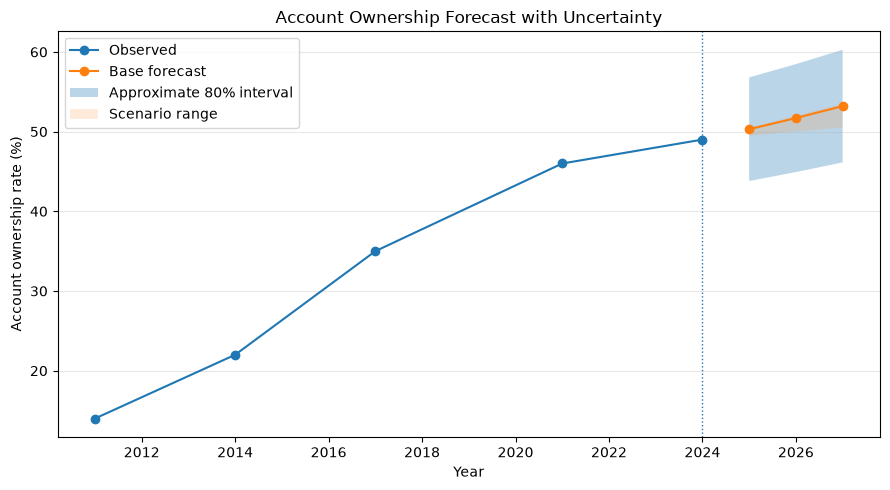

In [61]:
fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.plot(
    access_target["year"],
    access_target["access_rate"],
    marker="o",
    label="Observed",
)

ax.plot(
    access_uncertainty["year"],
    access_uncertainty["base"],
    marker="o",
    label="Base forecast",
)

ax.fill_between(
    access_uncertainty["year"],
    access_uncertainty["lower_80"],
    access_uncertainty["upper_80"],
    alpha=0.3,
    label="Approximate 80% interval",
)

ax.fill_between(
    access_uncertainty["year"],
    access_uncertainty["scenario_lower"],
    access_uncertainty["scenario_upper"],
    alpha=0.15,
    label="Scenario range",
)

ax.axvline(
    2024,
    linestyle=":",
    linewidth=1,
)

ax.set_title(
    "Account Ownership Forecast with Uncertainty"
)

ax.set_xlabel("Year")
ax.set_ylabel("Account ownership rate (%)")
ax.legend()
ax.grid(
    axis="y",
    alpha=0.3,
)

plt.tight_layout()
plt.show()

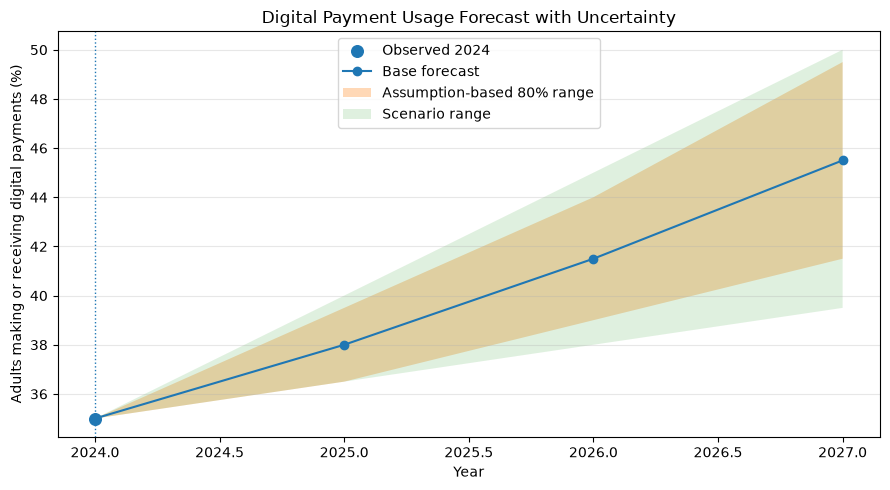

In [64]:
fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.scatter(
    usage_target["year"],
    usage_target["usage_rate"],
    s=70,
    label="Observed 2024",
)

scenario_years = np.insert(
    usage_uncertainty["year"].to_numpy(),
    0,
    latest_usage_year,
)

base_values = np.insert(
    usage_uncertainty["base"].to_numpy(),
    0,
    latest_usage_rate,
)

lower_values = np.insert(
    usage_uncertainty["lower_80"].to_numpy(),
    0,
    latest_usage_rate,
)

upper_values = np.insert(
    usage_uncertainty["upper_80"].to_numpy(),
    0,
    latest_usage_rate,
)

scenario_lower = np.insert(
    usage_uncertainty["pessimistic"].to_numpy(),
    0,
    latest_usage_rate,
)

scenario_upper = np.insert(
    usage_uncertainty["optimistic"].to_numpy(),
    0,
    latest_usage_rate,
)
ax.plot(
    scenario_years,
    base_values,
    marker="o",
    label="Base forecast",
)

ax.fill_between(
    scenario_years,
    lower_values,
    upper_values,
    alpha=0.3,
    label="Assumption-based 80% range",
)

ax.fill_between(
    scenario_years,
    scenario_lower,
    scenario_upper,
    alpha=0.15,
    label="Scenario range",
)

ax.axvline(
    2024,
    linestyle=":",
    linewidth=1,
)

ax.set_title(
    "Digital Payment Usage Forecast with Uncertainty"
)

ax.set_xlabel("Year")
ax.set_ylabel(
    "Adults making or receiving digital payments (%)"
)

ax.legend()
ax.grid(
    axis="y",
    alpha=0.3,
)

plt.tight_layout()
plt.show()

In [65]:
forecast_2027_uncertainty = pd.DataFrame({
    "target": [
        "Account Ownership Rate",
        "Digital Payment Usage",
    ],

    "base_2027": [
        access_uncertainty.loc[
            access_uncertainty["year"] == 2027,
            "base",
        ].iloc[0],

        usage_uncertainty.loc[
            usage_uncertainty["year"] == 2027,
            "base",
        ].iloc[0],
    ],

    "scenario_low_2027": [
        access_uncertainty.loc[
            access_uncertainty["year"] == 2027,
            "scenario_lower",
        ].iloc[0],

        usage_uncertainty.loc[
            usage_uncertainty["year"] == 2027,
            "pessimistic",
        ].iloc[0],
    ],

    "scenario_high_2027": [
        access_uncertainty.loc[
            access_uncertainty["year"] == 2027,
            "scenario_upper",
        ].iloc[0],

        usage_uncertainty.loc[
            usage_uncertainty["year"] == 2027,
            "optimistic",
        ].iloc[0],
    ],
})

forecast_2027_uncertainty

,target,base_2027,scenario_low_2027,scenario_high_2027
0,Account Ownership Rate,53.2,50.5,53.5
1,Digital Payment Usage,45.5,39.5,50.0


In [66]:
print("=" * 60)
print("FORECAST UNCERTAINTY SUMMARY")
print("=" * 60)

print(
    "\nAccess uncertainty method:",
    "Approximate model-based interval "
    "plus scenario range",
)

print(
    "Usage uncertainty method:",
    "Assumption-based interval "
    "plus scenario range",
)

print("\n2027 forecast ranges:")

print(
    "Account Ownership:",
    f"{access_scenarios.loc[access_scenarios['year'] == 2027, 'pessimistic'].iloc[0]:.1f}%"
    " to "
    f"{access_scenarios.loc[access_scenarios['year'] == 2027, 'optimistic'].iloc[0]:.1f}%",
)

print(
    "Digital Payment Usage:",
    f"{usage_scenarios.loc[usage_scenarios['year'] == 2027, 'pessimistic'].iloc[0]:.1f}%"
    " to "
    f"{usage_scenarios.loc[usage_scenarios['year'] == 2027, 'optimistic'].iloc[0]:.1f}%",
)

print(
    "\nMain limitation:",
    "Sparse historical data, especially for Usage",
)

FORECAST UNCERTAINTY SUMMARY

Access uncertainty method: Approximate model-based interval plus scenario range
Usage uncertainty method: Assumption-based interval plus scenario range

2027 forecast ranges:
Account Ownership: 50.5% to 53.5%
Digital Payment Usage: 39.5% to 50.0%

Main limitation: Sparse historical data, especially for Usage


In [67]:
forecast_interpretation = pd.DataFrame({
    "target": [
        "Account Ownership Rate",
        "Digital Payment Usage",
    ],
    "2024_baseline": [
        49.0,
        35.0,
    ],
    "2025_base": [
        50.3,
        38.0,
    ],
    "2026_base": [
        51.7,
        41.5,
    ],
    "2027_base": [
        53.2,
        45.5,
    ],
    "2027_pessimistic": [
        50.5,
        39.5,
    ],
    "2027_optimistic": [
        53.5,
        50.0,
    ],
})

forecast_interpretation

,target,2024_baseline,2025_base,2026_base,2027_base,2027_pessimistic,2027_optimistic
0,Account Ownership Rate,49.0,50.3,51.7,53.2,50.5,53.5
1,Digital Payment Usage,35.0,38.0,41.5,45.5,39.5,50.0


In [68]:
forecast_growth_summary = pd.DataFrame({
    "target": [
        "Account Ownership Rate",
        "Digital Payment Usage",
    ],
    "baseline_2024": [
        49.0,
        35.0,
    ],
    "base_2027": [
        53.2,
        45.5,
    ],
})

forecast_growth_summary[
    "change_2024_2027_pp"
] = (
    forecast_growth_summary["base_2027"]
    - forecast_growth_summary["baseline_2024"]
)

forecast_growth_summary[
    "relative_growth_percent"
] = (
    forecast_growth_summary[
        "change_2024_2027_pp"
    ]
    / forecast_growth_summary["baseline_2024"]
    * 100
).round(1)

forecast_growth_summary

,target,baseline_2024,base_2027,change_2024_2027_pp,relative_growth_percent
0,Account Ownership Rate,49.0,53.2,4.2,8.6
1,Digital Payment Usage,35.0,45.5,10.5,30.0


In [69]:
largest_potential_impacts = pd.DataFrame({
    "development": [
        "Telebirr and M-Pesa expansion",
        "Interoperability and QR payments",
        "Merchant and agent network growth",
        "Fayda Digital ID",
        "Pricing and affordability changes",
    ],
    "main_target": [
        "Usage and mobile money ownership",
        "Usage",
        "Usage and Access",
        "Access",
        "Usage",
    ],
    "expected_effect": [
        "Positive",
        "Positive",
        "Positive",
        "Positive",
        "Negative when costs rise",
    ],
    "confidence": [
        "Medium",
        "Medium",
        "Medium",
        "Low",
        "Low to medium",
    ],
})

largest_potential_impacts

,development,main_target,expected_effect,confidence
0,Telebirr and M-Pesa expansion,Usage and mobile money ownership,Positive,Medium
1,Interoperability and QR payments,Usage,Positive,Medium
2,Merchant and agent network growth,Usage and Access,Positive,Medium
3,Fayda Digital ID,Access,Positive,Low
4,Pricing and affordability changes,Usage,Negative when costs rise,Low to medium


In [70]:
interpretation_summary = pd.DataFrame({
    "question": [
        "What does the model predict?",
        "Which outcome grows faster?",
        "What events matter most?",
        "What is the largest uncertainty?",
    ],
    "answer": [
        (
            "By 2027, Account Ownership reaches 53.2% "
            "and Digital Payment Usage reaches 45.5% "
            "in the base scenario."
        ),
        (
            "Digital Payment Usage grows faster than "
            "Account Ownership."
        ),
        (
            "Mobile money expansion, interoperability, "
            "merchant networks and digital identification."
        ),
        (
            "The limited historical Usage data and the "
            "uncalibrated event-effect assumptions."
        ),
    ],
})

interpretation_summary

,question,answer
0,What does the model predict?,"By 2027, Account Ownership reaches 53.2% and D..."
1,Which outcome grows faster?,Digital Payment Usage grows faster than Accoun...
2,What events matter most?,"Mobile money expansion, interoperability, merc..."
3,What is the largest uncertainty?,The limited historical Usage data and the unca...


In [71]:
print("=" * 60)
print("FORECAST INTERPRETATION")
print("=" * 60)

print("\nBase forecast for 2027:")

print(
    "Account Ownership:",
    "53.2%",
)

print(
    "Digital Payment Usage:",
    "45.5%",
)

print("\n2027 scenario ranges:")

print(
    "Account Ownership:",
    "50.5% to 53.5%",
)

print(
    "Digital Payment Usage:",
    "39.5% to 50.0%",
)

print(
    "\nLargest expected impact:",
    "Mobile money expansion and interoperability, "
    "especially for Usage.",
)

print(
    "\nMain uncertainty:",
    "Only one direct historical Usage observation "
    "and qualitative event-effect estimates.",
)

FORECAST INTERPRETATION

Base forecast for 2027:
Account Ownership: 53.2%
Digital Payment Usage: 45.5%

2027 scenario ranges:
Account Ownership: 50.5% to 53.5%
Digital Payment Usage: 39.5% to 50.0%

Largest expected impact: Mobile money expansion and interoperability, especially for Usage.

Main uncertainty: Only one direct historical Usage observation and qualitative event-effect estimates.
